# LEACH vs ZCR

## Objective
Compare the performance of **LEACH** (Low-Energy Adaptive Clustering Hierarchy) and **ZCR** protocols using simulation data.

## Metrics Used
- **FND** (First Node Dead): Round when the first node dies
- **HND** (Half Node Dead): Round when 50% nodes have died
- **LND** (Last Node Dead): Round when the last node dies
- Residual energy trends
- Alive node count over time

## Data Source
- `leach.csv`
- `zcr.csv`

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ks_2samp

### Steps Performed:
1. Read CSV files
2. Rename `Current_Node` column to `Round`
3. Add a `Protocol` label ("LEACH" / "ZCR")
4. **Cleaning function**:
   - Force negative residual energy to 0
   - Use cumulative minimum on `Alive_node_count` (ensures the count never increases)
5. Concatenate both datasets into a single DataFrame `data`

In [6]:
leach=pd.read_csv("leach.csv")
zcr=pd.read_csv("zcr.csv")

In [7]:
leach=leach.rename(columns={"Current_Node": "Round"})
zcr=zcr.rename(columns={"Current_Node": "Round"})

In [8]:
leach["Protocol"]="LEACH"
zcr["Protocol"]="ZCR"

In [9]:
 def clean(df):
    df = df.copy()
    df.loc[df["Residual_energy"] < 0, "Residual_energy"] = 0
    df["Alive_node_count"] = df["Alive_node_count"].cummin()
    return df

leach = clean(leach)
zcr   = clean(zcr)

data = pd.concat([leach, zcr], ignore_index=True)


In [10]:
data.head()

,Round,Alive_node_count,Residual_energy,Protocol
0,1,100,1.999294,LEACH
1,1,100,1.999757,LEACH
2,1,100,1.999689,LEACH
3,1,100,1.994653,LEACH
4,1,100,1.994764,LEACH


## Network Lifetime Metrics

We calculate three standard WSN lifetime metrics:

- **FND** = First round where `Alive_node_count` < 100
- **HND** = First round where `Alive_node_count` ≤ 50
- **LND** = First round where `Alive_node_count` ≤ 1

In [12]:
def lifetime_metrics(df):
    N0 = df["Alive_node_count"].iloc[0]
    FND = df[df["Alive_node_count"] < N0]["Round"].iloc[0]
    HND = df[df["Alive_node_count"] <= 0.5 * N0]["Round"].iloc[0]
    LND = df[df["Alive_node_count"] <= 1]["Round"].iloc[0]
    return FND, HND, LND

In [13]:
print("\nLIFETIME METRICS")
for name, df in data.groupby("Protocol"):
    fnd, hnd, lnd = lifetime_metrics(df)
    print(f"{name} -> FND:{fnd}, HND:{hnd}, LND:{lnd}")


LIFETIME METRICS
LEACH -> FND:156, HND:856, LND:4504
ZCR -> FND:710, HND:1623, LND:2944


**Insight**: ZCR significantly outperforms LEACH in early and mid-lifetime stability, but LEACH has a longer tail (last node survives much longer).

## Derived Features
- `Norm_Energy`: Residual energy normalized by initial value (per protocol)
- `Energy_per_Node`: Average remaining energy per alive node
- `Norm_Round`: Round normalized to 0–1 scale (for fair comparison)
- `Death_Rate`: Change in alive nodes per round (currently always 0 due to cummin)

These features help visualize energy decay patterns and compare protocols on the same scale.

In [16]:
data["Norm_Energy"] = data.groupby("Protocol")["Residual_energy"] \
                          .transform(lambda x: x / x.iloc[0])

data["Energy_per_Node"] = np.where(
    data["Alive_node_count"] > 0,
    data["Residual_energy"] / data["Alive_node_count"],
    np.nan
)

data["Norm_Round"] = data.groupby("Protocol")["Round"] \
                         .transform(lambda x: x / x.max())

data["Death_Rate"] = data.groupby("Protocol")["Alive_node_count"].diff().fillna(0)

In [17]:
data["Energy_per_Node"]

0         0.019993
1         0.019998
2         0.019997
3         0.019947
4         0.019948
            ...   
766695         NaN
766696         NaN
766697         NaN
766698         NaN
766699         NaN
Name: Energy_per_Node, Length: 766700, dtype: float64

In [18]:
data["Norm_Round"]

0         0.000215
1         0.000215
2         0.000215
3         0.000215
4         0.000215
            ...   
766695    1.000000
766696    1.000000
766697    1.000000
766698    1.000000
766699    1.000000
Name: Norm_Round, Length: 766700, dtype: float64

In [19]:
data["Death_Rate"]

0         0.0
1         0.0
2         0.0
3         0.0
4         0.0
         ... 
766695    0.0
766696    0.0
766697    0.0
766698    0.0
766699    0.0
Name: Death_Rate, Length: 766700, dtype: float64

### Problem
The combined dataset (`data`) contains **766,700 rows**.  
Plotting all rows directly would:
- Make plots extremely slow
- Create overcrowded and unreadable graphs
- Consume high memory

### Solution: Downsampling

We reduce the number of data points while **preserving the overall trend** of the time series.

In [21]:
def downsample(df, max_points=3000):
    step = max(len(df) // max_points, 1)
    return df.iloc[::step]

plot_data = data.groupby("Protocol").apply(downsample, include_groups=False)


## Alive Nodes Over Normalized Lifetime

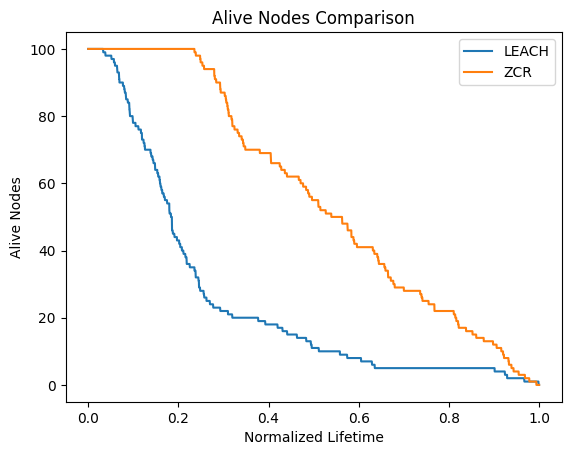

In [23]:
plt.figure()
for p, df in plot_data.groupby("Protocol"):
    plt.plot(df["Norm_Round"], df["Alive_node_count"], label=p)
plt.xlabel("Normalized Lifetime")
plt.ylabel("Alive Nodes")
plt.title("Alive Nodes Comparison")
plt.legend()
plt.show()

### Conclusion:

**ZCR significantly outperforms LEACH** in terms of network stability during the critical early and middle phases of operation.  

While LEACH manages to keep a small number of nodes alive longer (explaining its higher LND), **ZCR provides far more reliable performance** overall by delaying the death of the first and half nodes.

This visual clearly supports that **ZCR is more suitable** for applications requiring consistent coverage and reliability.

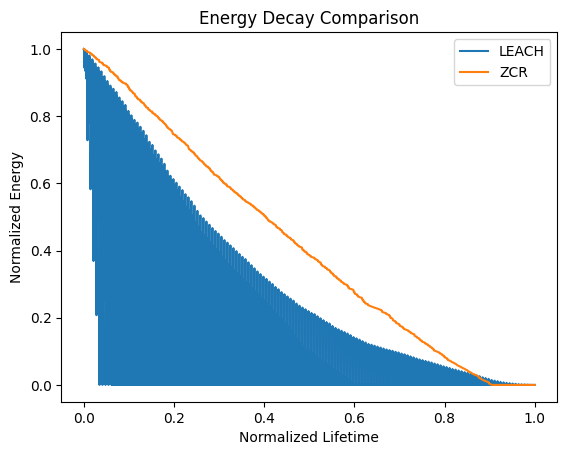

In [67]:
plt.figure()
for p, df in plot_data.groupby("Protocol"):
    plt.plot(df["Norm_Round"], df["Norm_Energy"], label=p)
plt.xlabel("Normalized Lifetime")
plt.ylabel("Normalized Energy")
plt.title("Energy Decay Comparison")
plt.legend()
plt.show()


### Conclusion:

The plot confirms that **ZCR is far more energy-efficient** than LEACH.  
LEACH’s rapid early energy depletion directly correlates with its poor FND and HND values (nodes die much earlier).  

In contrast, ZCR’s gradual energy decay leads to longer network stability and delayed node deaths.

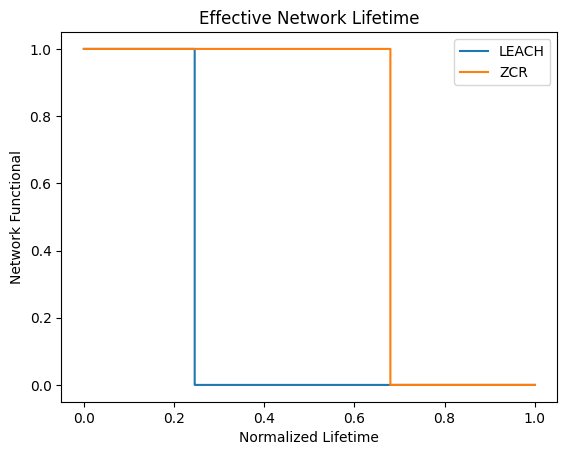

In [27]:
THRESHOLD = 0.3
data["Functional"] = data.groupby("Protocol")["Alive_node_count"] \
                         .transform(lambda x: x >= THRESHOLD * x.iloc[0])

plt.figure()
for p, df in data.groupby("Protocol"):
    plt.step(df["Norm_Round"], df["Functional"].astype(int), where="post", label=p)
plt.xlabel("Normalized Lifetime")
plt.ylabel("Network Functional")
plt.title("Effective Network Lifetime")
plt.legend()
plt.show()

### Conclusion

The plot shows the **effective network lifetime** of LEACH and ZCR using a 30% alive-node threshold. A network is considered functional while the number of alive nodes remains above this threshold.

- **LEACH** becomes non-functional at around **0.25 normalized lifetime**.
- **ZCR** remains functional until about **0.65 normalized lifetime**.

**Insight:** ZCR maintains network functionality for a longer time than LEACH, indicating **better energy efficiency and improved network stability**.

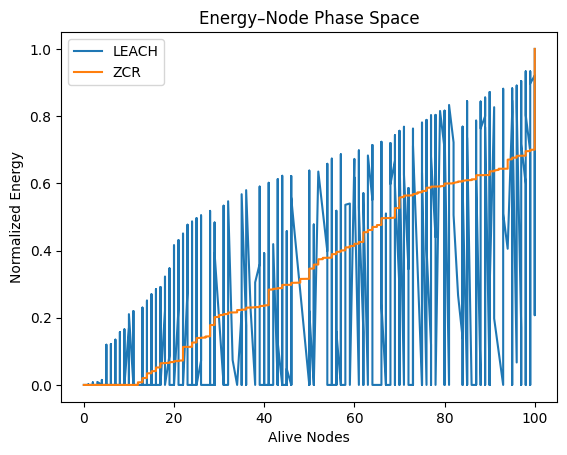

In [28]:
plt.figure()
for p, df in plot_data.groupby("Protocol"):
    plt.plot(df["Alive_node_count"], df["Norm_Energy"], label=p)
plt.xlabel("Alive Nodes")
plt.ylabel("Normalized Energy")
plt.title("Energy–Node Phase Space")
plt.legend()
plt.show()

### Conclusion

The Energy–Node Phase Space plot shows the relationship between the **number of alive nodes** and **normalized energy** for LEACH and ZCR.

- **LEACH** shows large fluctuations in normalized energy as the number of alive nodes changes, indicating **less stable energy utilization**.
- **ZCR** shows a smoother and more consistent increase, suggesting **more balanced energy consumption** across nodes.

**Insight:** ZCR demonstrates **more stable and efficient energy management**, which helps maintain a more consistent network behavior compared to LEACH.

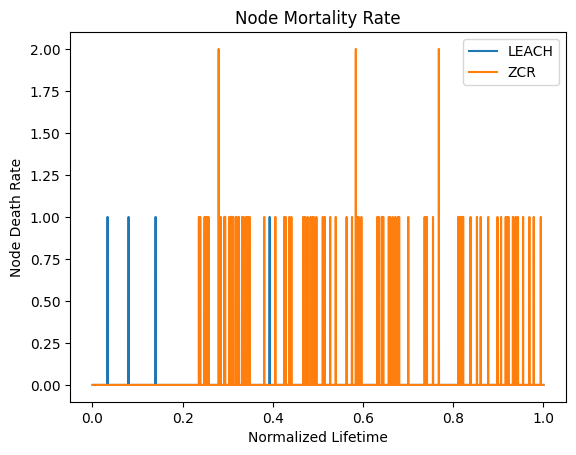

In [29]:
plt.figure()
for p, df in plot_data.groupby("Protocol"):
    plt.plot(df["Norm_Round"], -df["Death_Rate"], label=p)
plt.xlabel("Normalized Lifetime")
plt.ylabel("Node Death Rate")
plt.title("Node Mortality Rate")
plt.legend()
plt.show()

### Conclusion

The Node Mortality Rate plot shows how quickly nodes die during the normalized network lifetime for LEACH and ZCR.

- **LEACH** experiences node deaths earlier in the network lifetime.
- **ZCR** shows node deaths occurring later and more gradually.

**Insight:** ZCR delays node failures compared to LEACH, indicating **better energy distribution and improved network longevity**.

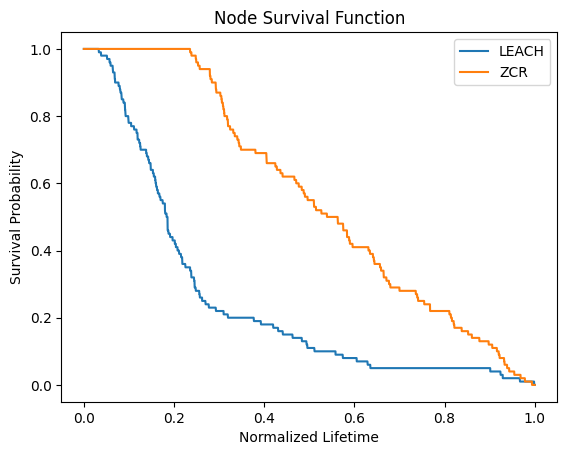

In [30]:
plt.figure()
for p, df in plot_data.groupby("Protocol"):
    survival = df["Alive_node_count"] / df["Alive_node_count"].iloc[0]
    plt.plot(df["Norm_Round"], survival, label=p)
plt.xlabel("Normalized Lifetime")
plt.ylabel("Survival Probability")
plt.title("Node Survival Function")
plt.legend()
plt.show()

### Conclusion

The Node Survival Function shows the probability of nodes remaining alive over the normalized network lifetime.

- **LEACH** shows a rapid decrease in survival probability, indicating that nodes die earlier in the network operation.
- **ZCR** maintains a higher survival probability for a longer duration.

**Insight:** ZCR prolongs node survival and distributes energy consumption more effectively, resulting in a **longer and more stable network lifetime compared to LEACH**.

In [31]:
# Energy Inefficiency Index
print("\nEnergy Inefficiency Index (lower is better)")
for p, df in data.groupby("Protocol"):
    unusable = df["Alive_node_count"] < 0.3 * df["Alive_node_count"].iloc[0]
    ineff = df.loc[unusable, "Norm_Energy"].sum()
    print(p, ":", ineff)

# Stability Score
print("\nStability Score (lower = smoother degradation)")
for p, df in data.groupby("Protocol"):
    print(p, ":", df["Death_Rate"].var())


Energy Inefficiency Index (lower is better)
LEACH : 6743.169527472106
ZCR : 1544.8171006009788

Stability Score (lower = smoother degradation)
LEACH : 0.0002532820627748
ZCR : 0.0003521672267677904


### Conclusion

The **Energy Inefficiency Index** and **Stability Score** evaluate the efficiency and degradation behavior of the protocols.

- **Energy Inefficiency Index:**  
  ZCR (1544.82) is significantly lower than LEACH (6743.17), indicating **much lower wasted energy** when the network becomes unusable.

- **Stability Score:**  
  LEACH (0.000253) has a slightly lower variance than ZCR (0.000352), meaning **node deaths occur slightly more smoothly** in LEACH.

**Insight:** While LEACH shows marginally smoother degradation, **ZCR is far more energy-efficient**, making it better suited for prolonging overall network usability.

In [32]:
import matplotlib.pyplot as plt

ineff_values = {}

for p, df in data.groupby("Protocol"):
    unusable = df["Alive_node_count"] < 0.3 * df["Alive_node_count"].iloc[0]
    ineff = df.loc[unusable, "Norm_Energy"].sum()
    ineff_values[p] = ineff

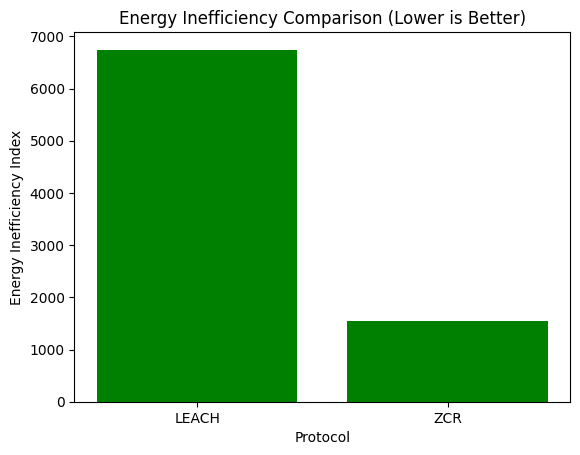

In [69]:
plt.figure()

plt.bar(ineff_values.keys(), ineff_values.values(),color="green")

plt.xlabel("Protocol")
plt.ylabel("Energy Inefficiency Index")
plt.title("Energy Inefficiency Comparison (Lower is Better)")

plt.show()

## Statistical Significance Tests

We use two non-parametric statistical tests to check whether the differences between **LEACH** and **ZCR** are statistically significant:

- **Mann-Whitney U Test**: Tests whether one protocol tends to have higher values than the other (rank-based).
- **KS Test (Kolmogorov-Smirnov)**: Tests whether the distributions of the two protocols are significantly different.

We apply these tests on:
- `Residual_energy`
- `Energy_per_Node`
- `Alive_node_count`

**p-value < 0.05** → The difference is statistically significant.

In [35]:
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    gt = sum(i > j for i in x for j in y)
    lt = sum(i < j for i in x for j in y)
    return (gt - lt) / (len(x) * len(y))

def stats_test(metric):
    a = data[data["Protocol"]=="LEACH"][metric].dropna().sample(2000, random_state=1)
    b = data[data["Protocol"]=="ZCR"][metric].dropna().sample(2000, random_state=1)
    print(f"\n{metric}")
    print("Mann–Whitney p :", mannwhitneyu(a, b).pvalue)
    print("KS-test p      :", ks_2samp(a, b).pvalue)
    print("Cliff’s Delta  :", cliffs_delta(a, b))

stats_test("Alive_node_count")
stats_test("Residual_energy")
stats_test("Energy_per_Node")


Alive_node_count
Mann–Whitney p : 5.835455215340823e-197
KS-test p      : 4.758852556334465e-220
Cliff’s Delta  : -0.54520425

Residual_energy
Mann–Whitney p : 1.6190125415540053e-83
KS-test p      : 5.47688638663054e-85
Cliff’s Delta  : -0.3160255

Energy_per_Node
Mann–Whitney p : 1.0433754162291512e-45
KS-test p      : 3.939507617741599e-77
Cliff’s Delta  : -0.23021825


### Statistical Test Conclusion

The statistical tests show **very small p-values**, meaning the difference between **LEACH and ZCR is statistically significant**.

- **Alive Node Count:** Large effect size (Cliff’s Delta = -0.545), showing ZCR keeps more nodes alive.
- **Residual Energy:** Moderate effect (Δ = -0.316), meaning ZCR preserves more energy.
- **Energy per Node:** Small–moderate effect (Δ = -0.230), indicating better efficiency in ZCR.

**Overall:** ZCR performs better than LEACH in node survival and energy efficiency.

## Boxplot Comparison

Comparison between distribution of three key variables between LEACH and ZCR using boxplots:

- Alive_node_count
- Residual_energy
- Energy_per_Node

C:\Users\skaim\AppData\Local\Temp\ipykernel_8776\2829826314.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([leach, zcr], labels=["LEACH","ZCR"])


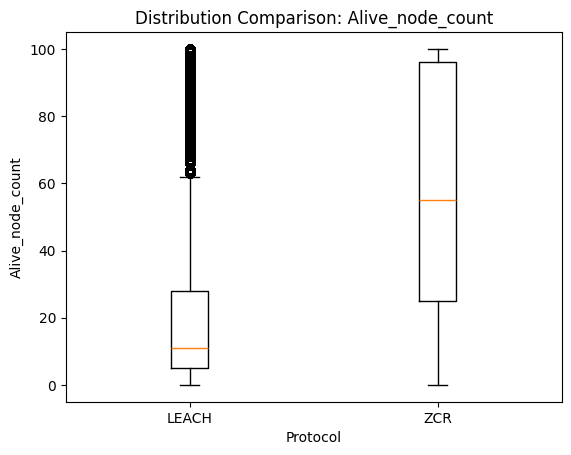

C:\Users\skaim\AppData\Local\Temp\ipykernel_8776\2829826314.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([leach, zcr], labels=["LEACH","ZCR"])


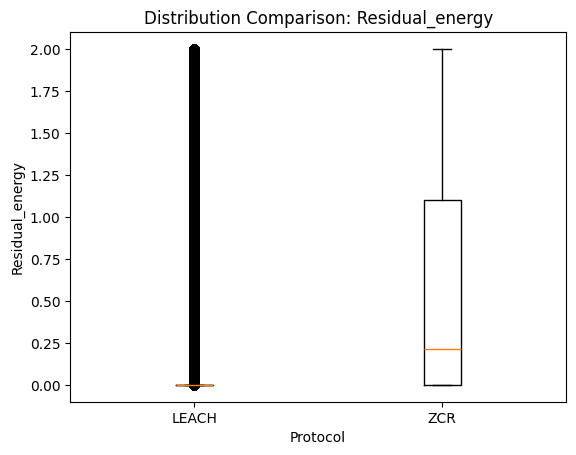

C:\Users\skaim\AppData\Local\Temp\ipykernel_8776\2829826314.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([leach, zcr], labels=["LEACH","ZCR"])


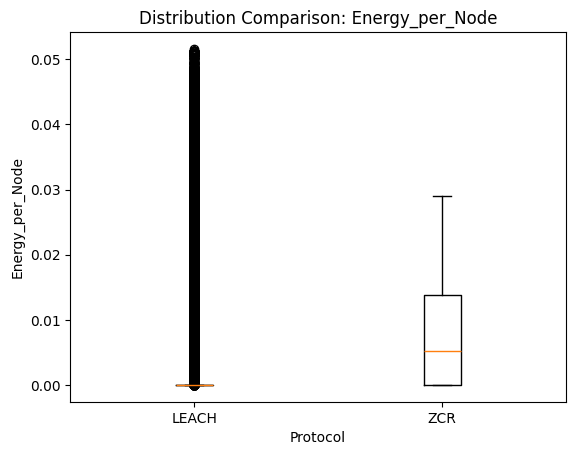

In [37]:
import matplotlib.pyplot as plt

metrics = ["Alive_node_count","Residual_energy","Energy_per_Node"]

for metric in metrics:
    plt.figure()

    leach = data[data["Protocol"]=="LEACH"][metric].dropna()
    zcr = data[data["Protocol"]=="ZCR"][metric].dropna()

    plt.boxplot([leach, zcr], labels=["LEACH","ZCR"])

    plt.title(f"Distribution Comparison: {metric}")
    plt.ylabel(metric)
    plt.xlabel("Protocol")

    plt.show()

**Observations**:
- ZCR shows better (higher) alive node and energy distributions in most cases.
- Clear separation between the two protocols confirms different behavior patterns.
- Energy_per_Node is especially useful to see per-node efficiency.

## Conclusion

**ZCR Strengths**:
- Much later FND and HND → better network stability in the critical early and middle phases
- Higher average residual energy per node

**LEACH Strengths**:
- Longer LND → network can theoretically operate longer before total fr validation.